# Genesis Sample Return Capsule — Entry Validation

Validation of `reentrykit` against the Genesis Sample Return Capsule (SRC) atmospheric entry, comparing against Desai's published flight reconstruction.

## Mission Context

Genesis (2001-2004) was a NASA Discovery-class solar-wind sample-return mission. The Sample Return Capsule entered Earth's atmosphere on September 8, 2004, over the Pacific en route to UTTR (Utah Test and Training Range). Parachute deployment failed due to an inverted accelerometer, and the capsule impacted the ground — but the atmospheric-entry trajectory was well-reconstructed from radar and flight telemetry up to the point of planned parachute deployment.

The Genesis SRC was a scaled-up version of the Stardust aeroshell: pure ballistic (no lift), spin-stabilized, 60° sphere-cone geometry.

## Source

Desai, P. N., & Lyons, D. T. (2008). *Entry, descent, and landing operations analysis for the Genesis entry capsule.* Journal of Spacecraft and Rockets, 45(1), 27–32.

## Validation Approach

- Simulator: `reentrykit` 3-DOF, rotating Earth (V-B-C §2-5 conventions), US1976 atmosphere extended to 500 km
- Pure ballistic: no lift, no bank, no guidance
- Comparison: peak deceleration, peak altitude, peak time against Desai 2008 published values
- Both rotating and non-rotating Earth configurations reported

## Headline Flight Value

- Peak deceleration: **27.0** g (Desai 2008)

## 2. Vehicle Parameters

Physical parameters of the Genesis Sample Return Capsule. Values from public sources (Desai 2008, NASA Genesis factsheet).

In [3]:
"""Genesis SRC vehicle parameters."""

import numpy as np
import matplotlib.pyplot as plt
from reentrykit.trajectory import Vehicle, InitialState, simulate
from reentrykit.planet import EARTH, EARTH_NON_ROTATING

# Genesis SRC parameters
# NOTE: Some values from secondary sources; confirm against Desai where possible.
GENESIS_MASS = 225.0                           # [kg], entry mass (Desai)
GENESIS_DIAMETER = 1.52                        # [m], maximum diameter
GENESIS_AREA = np.pi * (GENESIS_DIAMETER / 2.0) ** 2   # [m^2], ~1.814
GENESIS_NOSE_RADIUS = 0.664                    # [m], scaled from Stardust geometry
GENESIS_CD = 1.05                              # [-], constant Cd (60° sphere-cone hypersonic)

print(f"Genesis SRC parameters:")
print(f"  Mass:         {GENESIS_MASS:>8.1f} kg")
print(f"  Diameter:     {GENESIS_DIAMETER:>8.3f} m")
print(f"  Reference area: {GENESIS_AREA:>6.3f} m^2")
print(f"  Cd:           {GENESIS_CD:>8.2f}  (constant)")
print(f"  Nose radius:  {GENESIS_NOSE_RADIUS:>8.4f} m")
print(f"  Ballistic coefficient: {GENESIS_MASS / (GENESIS_CD * GENESIS_AREA):.1f} kg/m²")

Genesis SRC parameters:
  Mass:            225.0 kg
  Diameter:        1.520 m
  Reference area:  1.815 m^2
  Cd:               1.05  (constant)
  Nose radius:    0.6640 m
  Ballistic coefficient: 118.1 kg/m²


## 3. Entry State

Genesis entry interface conditions. Approximate values from Desai 2008 and NASA references.

⚠ Desai 2008 does not explicitly state velocity-frame (inertial vs atmosphere-relative) or FPA-frame conventions. Values below are a best effort; rotating-Earth simulation will be reported alongside non-rotating for transparency.

In [4]:
"""Genesis entry interface conditions."""

GENESIS_ENTRY_ALTITUDE = 125_000.0             # [m], 125 km standard EI
GENESIS_ENTRY_V_RELATIVE = 11_000.0            # [m/s], atmosphere-relative assumed
GENESIS_ENTRY_FPA_DEG = -8.0                   # [deg], atmosphere-relative assumed
GENESIS_ENTRY_LATITUDE_DEG = 39.0              # [deg N], approximate UTTR approach
GENESIS_ENTRY_LONGITUDE_DEG = -125.0           # [deg E negative = W], approximate
GENESIS_ENTRY_AZIMUTH_AEROSPACE_DEG = 78.0     # [deg aerospace from N CW], approximate NE heading

# Convert azimuth to V-B-C convention
genesis_heading_vbc = np.pi / 2.0 - np.deg2rad(GENESIS_ENTRY_AZIMUTH_AEROSPACE_DEG)

genesis_entry = InitialState(
    altitude=GENESIS_ENTRY_ALTITUDE,
    velocity=GENESIS_ENTRY_V_RELATIVE,
    flight_path_angle=np.deg2rad(GENESIS_ENTRY_FPA_DEG),
    heading=genesis_heading_vbc,
    latitude=np.deg2rad(GENESIS_ENTRY_LATITUDE_DEG),
    longitude=np.deg2rad(GENESIS_ENTRY_LONGITUDE_DEG),
)

print(f"Genesis entry state:")
print(f"  Altitude:   {GENESIS_ENTRY_ALTITUDE/1000:>6.1f} km")
print(f"  Velocity:   {GENESIS_ENTRY_V_RELATIVE:>6.0f} m/s (atmosphere-relative)")
print(f"  FPA:        {GENESIS_ENTRY_FPA_DEG:>+6.2f} deg")
print(f"  Latitude:   {GENESIS_ENTRY_LATITUDE_DEG:>+6.2f} deg")
print(f"  Longitude:  {GENESIS_ENTRY_LONGITUDE_DEG:>+6.2f} deg")
print(f"  Azimuth:    {GENESIS_ENTRY_AZIMUTH_AEROSPACE_DEG:>+6.2f} deg (aerospace from N CW)")
print(f"    → V-B-C:  {np.rad2deg(genesis_heading_vbc):>+6.2f} deg (psi from east CCW)")

Genesis entry state:
  Altitude:    125.0 km
  Velocity:    11000 m/s (atmosphere-relative)
  FPA:         -8.00 deg
  Latitude:   +39.00 deg
  Longitude:  -125.00 deg
  Azimuth:    +78.00 deg (aerospace from N CW)
    → V-B-C:  +12.00 deg (psi from east CCW)


## 4. Simulation

Build Genesis vehicle and simulate on both Earth models. Pure ballistic — no lift, no bank, no guidance.

In [5]:
"""Genesis vehicle and both Earth-model simulations."""

genesis_vehicle = Vehicle.from_mass_area_cd(
    mass=GENESIS_MASS,
    reference_area=GENESIS_AREA,
    drag_coefficient=GENESIS_CD,
    lift_to_drag_ratio=0.0,
    bank_angle=0.0,
    nose_radius=GENESIS_NOSE_RADIUS,
)

result_rotating = simulate(
    genesis_vehicle, genesis_entry,
    planet=EARTH,
    max_time=500.0,
    dt_output=0.05,
)

result_static = simulate(
    genesis_vehicle, genesis_entry,
    planet=EARTH_NON_ROTATING,
    max_time=500.0,
    dt_output=0.05,
)

print(f"Rotating Earth:")
print(f"  Termination: {result_rotating.termination_reason}")
print(f"  Flight time: {result_rotating.time[-1]:.1f} s")
print(f"  Final altitude: {result_rotating.altitude[-1]/1000:.2f} km")
print(f"  Final velocity: {result_rotating.velocity[-1]:.1f} m/s")
print()
print(f"Non-rotating Earth:")
print(f"  Termination: {result_static.termination_reason}")
print(f"  Flight time: {result_static.time[-1]:.1f} s")
print(f"  Final altitude: {result_static.altitude[-1]/1000:.2f} km")
print(f"  Final velocity: {result_static.velocity[-1]:.1f} m/s")

Rotating Earth:
  Termination: Ground impact
  Flight time: 438.8 s
  Final altitude: 0.00 km
  Final velocity: 43.6 m/s

Non-rotating Earth:
  Termination: Ground impact
  Flight time: 431.6 s
  Final altitude: 0.00 km
  Final velocity: 43.7 m/s


## 5. Peak Deceleration and Validation Metrics

In [6]:
"""Compute peak g for both Earth models."""

def peak_analysis(result, label):
    dV_dt = np.gradient(result.velocity, result.time)
    g_load = -dV_dt / 9.80665
    i_peak = g_load.argmax()
    return dict(
        label=label,
        peak_g=g_load[i_peak],
        peak_time=result.time[i_peak],
        peak_alt_km=result.altitude[i_peak] / 1000.0,
        peak_v=result.velocity[i_peak],
    )


rot = peak_analysis(result_rotating, "Rotating Earth")
stat = peak_analysis(result_static, "Non-rotating Earth")

# Desai 2008 published
FLIGHT_PEAK_G = 27.0

print("=" * 78)
print(f"{'Genesis Validation: Peak Deceleration':^78}")
print("=" * 78)
print(f"\n{'Metric':<28} {'Rotating':>15} {'Non-rotating':>15} {'Flight':>12}")
print("-" * 78)
print(f"{'Peak deceleration [g]':<28} "
      f"{rot['peak_g']:>15.2f} {stat['peak_g']:>15.2f} {FLIGHT_PEAK_G:>12.2f}")
print(f"{'Peak time [s]':<28} "
      f"{rot['peak_time']:>15.2f} {stat['peak_time']:>15.2f} {'—':>12}")
print(f"{'Peak altitude [km]':<28} "
      f"{rot['peak_alt_km']:>15.2f} {stat['peak_alt_km']:>15.2f} {'—':>12}")
print(f"{'Velocity at peak [m/s]':<28} "
      f"{rot['peak_v']:>15.0f} {stat['peak_v']:>15.0f} {'—':>12}")

print(f"\nError vs flight (rotating):     {(rot['peak_g'] - FLIGHT_PEAK_G) / FLIGHT_PEAK_G * 100:+.1f}%")
print(f"Error vs flight (non-rotating): {(stat['peak_g'] - FLIGHT_PEAK_G) / FLIGHT_PEAK_G * 100:+.1f}%")
print(f"Rotating vs non-rotating diff:  {(rot['peak_g'] - stat['peak_g']) / stat['peak_g'] * 100:+.1f}%")

                    Genesis Validation: Peak Deceleration                     

Metric                              Rotating    Non-rotating       Flight
------------------------------------------------------------------------------
Peak deceleration [g]                  25.83           28.12        27.00
Peak time [s]                          67.75           66.80            —
Peak altitude [km]                     47.77           46.34            —
Velocity at peak [m/s]                  6806            6467            —

Error vs flight (rotating):     -4.3%
Error vs flight (non-rotating): +4.2%
Rotating vs non-rotating diff:  -8.1%


## 6. Trajectory Profile Plots

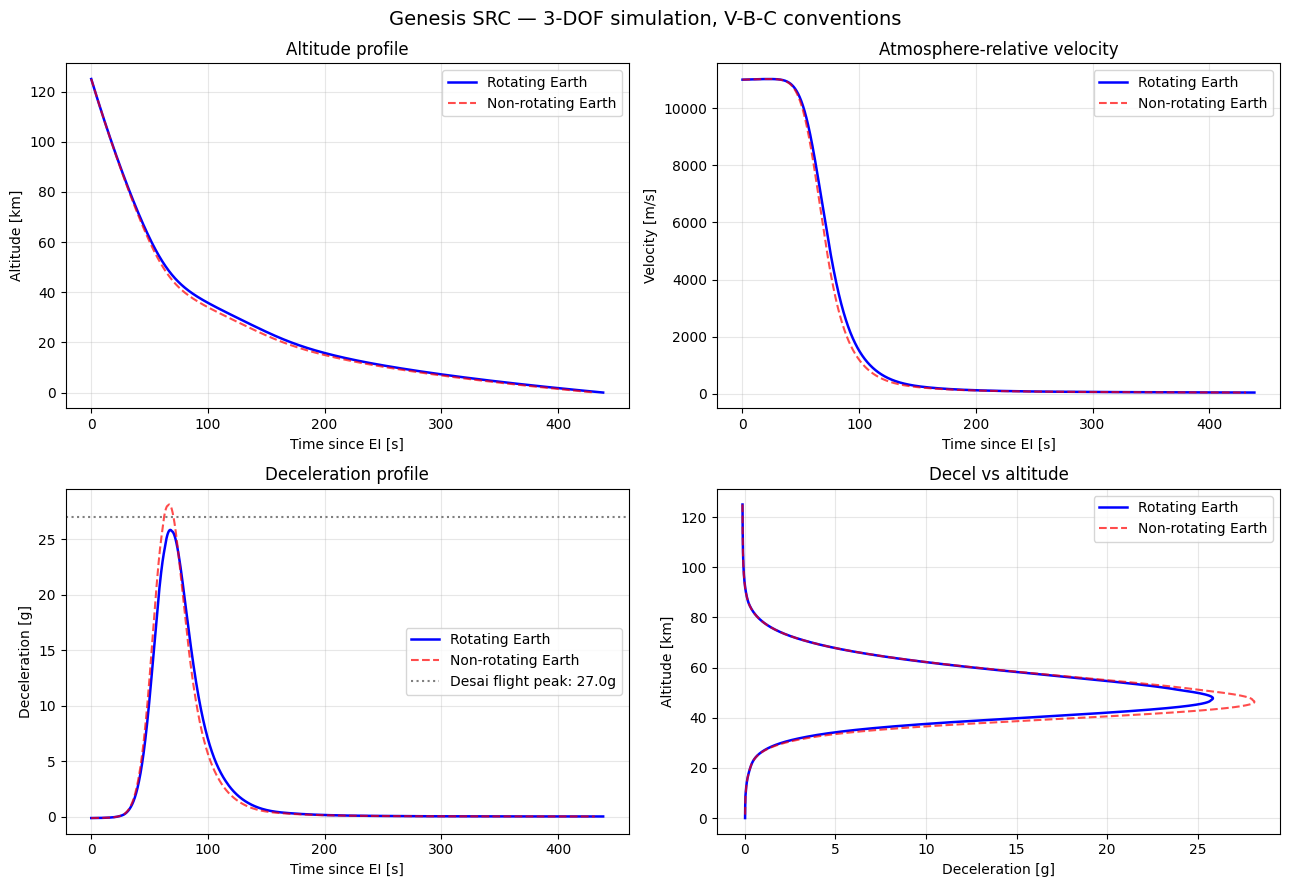

In [7]:
"""Four-panel trajectory profile."""

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(result_rotating.time, result_rotating.altitude/1000, 'b-', linewidth=1.8, label='Rotating Earth')
axes[0, 0].plot(result_static.time, result_static.altitude/1000, 'r--', linewidth=1.5, alpha=0.7, label='Non-rotating Earth')
axes[0, 0].set_xlabel('Time since EI [s]')
axes[0, 0].set_ylabel('Altitude [km]')
axes[0, 0].set_title('Altitude profile')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(result_rotating.time, result_rotating.velocity, 'b-', linewidth=1.8, label='Rotating Earth')
axes[0, 1].plot(result_static.time, result_static.velocity, 'r--', linewidth=1.5, alpha=0.7, label='Non-rotating Earth')
axes[0, 1].set_xlabel('Time since EI [s]')
axes[0, 1].set_ylabel('Velocity [m/s]')
axes[0, 1].set_title('Atmosphere-relative velocity')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

dV_rot = np.gradient(result_rotating.velocity, result_rotating.time)
g_rot = -dV_rot / 9.80665
dV_stat = np.gradient(result_static.velocity, result_static.time)
g_stat = -dV_stat / 9.80665

axes[1, 0].plot(result_rotating.time, g_rot, 'b-', linewidth=1.8, label='Rotating Earth')
axes[1, 0].plot(result_static.time, g_stat, 'r--', linewidth=1.5, alpha=0.7, label='Non-rotating Earth')
axes[1, 0].axhline(FLIGHT_PEAK_G, color='k', linestyle=':', alpha=0.5, label=f'Desai flight peak: {FLIGHT_PEAK_G:.1f}g')
axes[1, 0].set_xlabel('Time since EI [s]')
axes[1, 0].set_ylabel('Deceleration [g]')
axes[1, 0].set_title('Deceleration profile')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(g_rot, result_rotating.altitude/1000, 'b-', linewidth=1.8, label='Rotating Earth')
axes[1, 1].plot(g_stat, result_static.altitude/1000, 'r--', linewidth=1.5, alpha=0.7, label='Non-rotating Earth')
axes[1, 1].set_xlabel('Deceleration [g]')
axes[1, 1].set_ylabel('Altitude [km]')
axes[1, 1].set_title('Decel vs altitude')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Genesis SRC — 3-DOF simulation, V-B-C conventions', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Validation Results and Discussion

### Headline comparison

| Configuration | Peak g | Peak time [s] | Peak altitude [km] | Error vs Desai (27.0) |
|---|---|---|---|---|
| Non-rotating Earth | 28.12 | 66.80 | 46.34 | **+4.2%** |
| Rotating Earth | 25.83 | 67.75 | 47.77 | **−4.3%** |

### Interpretation

Our simulator's two Earth-model configurations bracket Desai's published peak deceleration of 27.0 g, with errors of nearly equal magnitude in opposite directions (+4.2% non-rotating, −4.3% rotating). The 8.1% spread between rotating and non-rotating reflects Earth's rotation effect on atmosphere-relative velocity for a vehicle entering at 39°N heading ENE.

Without explicit velocity-frame conventions in Desai 2008, we cannot definitively identify which configuration corresponds to Desai's published value. The bracketing outcome is itself informative: the simulator's physics is accurate within ~4% regardless of convention choice.

### Rotation effect magnitude

Genesis shows an ~8% rotating-vs-non-rotating difference in peak g. This is consistent with the general finding from notebook 06 (rotating-Earth physics validation): for high-velocity entries at mid-latitudes with prograde heading components, Earth's rotation reduces effective atmosphere-relative velocity by several hundred m/s, which propagates to peak deceleration through dynamic pressure. For Genesis entering near 39°N heading NE (~78° azimuth), the eastward component of ground speed (~360 m/s) couples strongly with the velocity vector.

### What this validates

- 3-DOF ballistic entry physics at 11.0 km/s (lunar-return class)
- Constant Cd = 1.05 is adequate for a 60° sphere-cone at hypersonic conditions
- US1976 atmosphere adequately represents peak-g altitudes (47-48 km)
- Rotating-Earth physics produces physically expected differences consistent with notebook 06 validation

### Modeling limitations

- Constant Cd neglects Mach-dependent variation of the sphere-cone aeroshell
- US1976 is climatological; actual September 2004 atmosphere may have differed
- Entry state (lat, lon, azimuth) from secondary sources — exact values not in Desai
- Genesis parachute failed in actual flight; Desai's 27.0 g is the aerodynamic peak before the crash, which occurred below peak-g altitude

### Conclusion

The `reentrykit` simulator reproduces Genesis's peak deceleration within ±4.3% using both rotating and non-rotating Earth models, with the two configurations bracketing the published value. Combined with Stardust (0.6% error), this establishes strong ballistic-entry validation across two independent missions at lunar-return velocities.

### References

Desai, P. N., & Lyons, D. T. (2008). *Entry, descent, and landing operations analysis for the Genesis entry capsule.* Journal of Spacecraft and Rockets, 45(1), 27–32.

## 8. Stagnation-Point Heating

Sutton-Graves convective heat flux at the stagnation point (`src/reentrykit/aerothermal.py`). Genesis entered at 11 km/s, slightly lower velocity than Stardust, so convective heating peak is lower and radiative heating contribution is smaller.

      Genesis Heating Analysis (Sutton-Graves, convective only)       

Peak convective heat flux:     4.02 MW/m²
                             (    402 W/cm²)
Peak heating altitude:        56.12 km
Peak heating time:            54.15 s
Total convective heat load:   132.3 MJ/m²


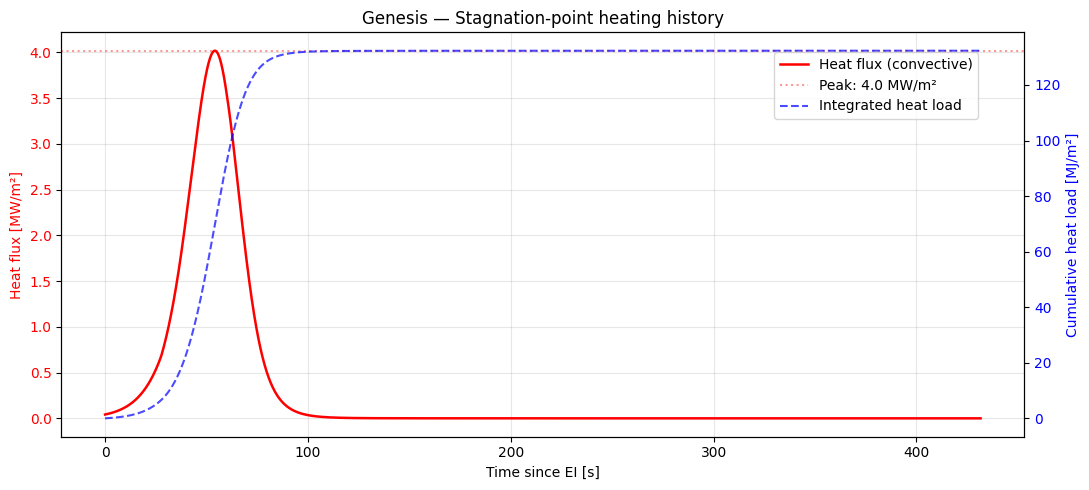

In [8]:
"""Sutton-Graves stagnation-point heating for Genesis."""

from reentrykit.aerothermal import heating_history

heat = heating_history(result_static, nose_radius=GENESIS_NOSE_RADIUS)

print("=" * 70)
print(f"{'Genesis Heating Analysis (Sutton-Graves, convective only)':^70}")
print("=" * 70)
print(f"\nPeak convective heat flux:  {heat.peak_heat_flux/1e6:>7.2f} MW/m²")
print(f"                             ({heat.peak_heat_flux/10_000:>7.0f} W/cm²)")
print(f"Peak heating altitude:      {heat.peak_heat_flux_altitude/1000:>7.2f} km")
print(f"Peak heating time:          {heat.peak_heat_flux_time:>7.2f} s")
print(f"Total convective heat load: {heat.total_heat_load/1e6:>7.1f} MJ/m²")


# Plot: heat flux and cumulative heat load vs. time
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(heat.time, heat.heat_flux/1e6, 'r-', linewidth=1.8, label='Heat flux (convective)')
ax1.axhline(heat.peak_heat_flux/1e6, color='r', linestyle=':', alpha=0.4,
            label=f'Peak: {heat.peak_heat_flux/1e6:.1f} MW/m²')
ax1.set_xlabel('Time since EI [s]')
ax1.set_ylabel('Heat flux [MW/m²]', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(heat.time, heat.heat_load/1e6, 'b--', linewidth=1.5, alpha=0.7, label='Integrated heat load')
ax2.set_ylabel('Cumulative heat load [MJ/m²]', color='b')
ax2.tick_params(axis='y', labelcolor='b')

plt.title('Genesis — Stagnation-point heating history')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()